## Name: Bibek Itani
## Course: Advanced Big Data and Data Mining (MSCS-634-M20)
## Lab Assignment: Regression Analysis with Regularization Techniques

Data Preparation

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['TARGET'] = diabetes.target

# Explore Dataset
print("Dataset Info:")
print(df.info())
print("\nDataset Description:")
print(df.describe())

# Check for missing values (Diabetes dataset comes pre-cleaned, but good practice)
print("\nMissing Values:")
print(df.isnull().sum())

# Define evaluation helper function
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} Performance ---")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}\n")
    return mae, mse, rmse, r2

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  TARGET  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None

Dataset Description:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256

## Step 2: Linear Regression
## Implementing a Simple Linear Regression using a single feature (BMI) to predict disease progression.

--- Simple Linear Regression (BMI) Performance ---
MAE:  52.2600
MSE:  4061.8259
RMSE: 63.7325
R²:   0.2334



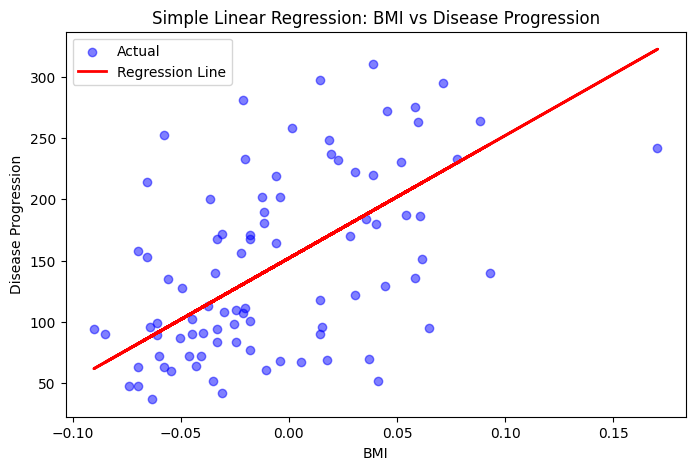

In [7]:
# Using 'bmi' as the single independent variable
X_simple = df[['bmi']]
y = df['TARGET']

X_train_s, X_test_s, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# Train
lr_simple = LinearRegression()
lr_simple.fit(X_train_s, y_train)
y_pred_s = lr_simple.predict(X_test_s)

# Evaluate
eval_simple = evaluate_model(y_test, y_pred_s, "Simple Linear Regression (BMI)")

# Visualize
plt.figure(figsize=(8, 5))
plt.scatter(X_test_s, y_test, color='blue', alpha=0.5, label='Actual')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: BMI vs Disease Progression')
plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.legend()
plt.show()

## Step 3: Multiple Regression
Using all available features to predict the target variable.

--- Multiple Regression Performance ---
MAE:  42.7941
MSE:  2900.1936
RMSE: 53.8534
R²:   0.4526



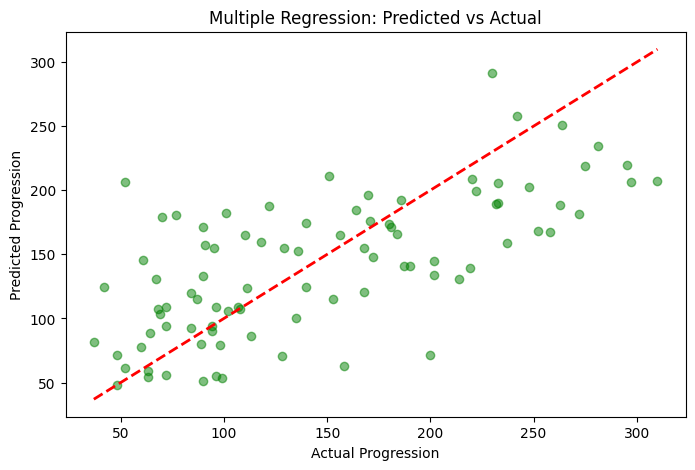

In [9]:
# Using all features
X_multi = df.drop(columns=['TARGET'])

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Train
lr_multi = LinearRegression()
lr_multi.fit(X_train_m, y_train_m)
y_pred_m = lr_multi.predict(X_test_m)

# Evaluate
eval_multi = evaluate_model(y_test_m, y_pred_m, "Multiple Regression")

# Visualize Predicted vs Actual
plt.figure(figsize=(8, 5))
plt.scatter(y_test_m, y_pred_m, color='green', alpha=0.5)
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'r--', lw=2)
plt.title('Multiple Regression: Predicted vs Actual')
plt.xlabel('Actual Progression')
plt.ylabel('Predicted Progression')
plt.show()

## Step 4: Polynomial Regression
Extending the linear model with polynomial features (Degree 2). 
Increasing the degree too high (e.g., Degree 3 or 4) creates overly complex curves that fit the training noise perfectly but fail on unseen data (overfitting). A very low degree (like 1) might miss the underlying pattern (underfitting).

In [10]:
# Create polynomial features
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_m)
X_test_poly = poly.transform(X_test_m)

# Train
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_m)
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluate
eval_poly = evaluate_model(y_test_m, y_pred_poly, "Polynomial Regression (Degree 2)")

--- Polynomial Regression (Degree 2) Performance ---
MAE:  43.5817
MSE:  3096.0283
RMSE: 55.6420
R²:   0.4156



/Users/151270/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/151270/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/151270/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


## Step 5: Regularization with Ridge and Lasso
Regularization introduces a penalty to the loss function to constrain model complexity.
* **Ridge (L2)** shrinks coefficients evenly to prevent extreme weights.
* **Lasso (L1)** can shrink coefficients exactly to zero, effectively performing feature selection.
The `alpha` parameter controls the penalty strength: higher alpha = more regularization.

--- Ridge Regression Performance ---
MAE:  44.4161
MSE:  2917.1766
RMSE: 54.0109
R²:   0.4494

--- Lasso Regression Performance ---
MAE:  44.9152
MSE:  2945.1489
RMSE: 54.2692
R²:   0.4441



/Users/151270/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/151270/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/151270/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


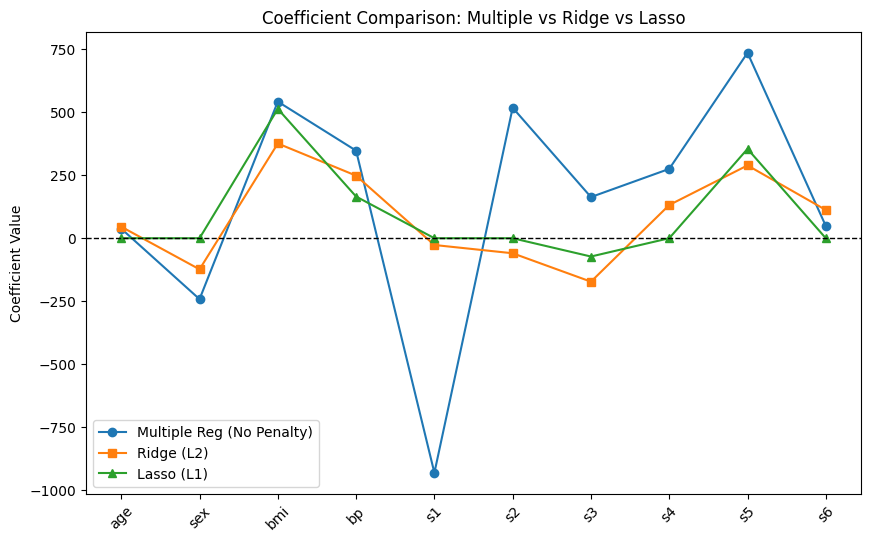

In [11]:
alpha_val = 0.5 # Regularization strength

# Ridge Regression
ridge = Ridge(alpha=alpha_val)
ridge.fit(X_train_m, y_train_m)
y_pred_ridge = ridge.predict(X_test_m)
eval_ridge = evaluate_model(y_test_m, y_pred_ridge, "Ridge Regression")

# Lasso Regression
lasso = Lasso(alpha=alpha_val)
lasso.fit(X_train_m, y_train_m)
y_pred_lasso = lasso.predict(X_test_m)
eval_lasso = evaluate_model(y_test_m, y_pred_lasso, "Lasso Regression")

# Visualizing the Coefficient shrinkage
plt.figure(figsize=(10, 6))
plt.plot(lr_multi.coef_, marker='o', label='Multiple Reg (No Penalty)')
plt.plot(ridge.coef_, marker='s', label='Ridge (L2)')
plt.plot(lasso.coef_, marker='^', label='Lasso (L1)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xticks(ticks=range(len(X_multi.columns)), labels=X_multi.columns, rotation=45)
plt.title('Coefficient Comparison: Multiple vs Ridge vs Lasso')
plt.ylabel('Coefficient Value')
plt.legend()
plt.show()

## Step 6: Model Comparison and Analysis

### Key Observations:
1. **Model Performance**: Multiple Regression significantly outperformed Simple Linear Regression. Relying solely on BMI ignores other critical health indicators like blood pressure and serum measurements.
2. **Overfitting & Polynomials**: The Polynomial Regression (Degree 2) likely exhibited signs of overfitting (higher RMSE/lower R² on the test set compared to Multiple Regression) because squaring 10 features creates high dimensionality relative to the small dataset size (442 samples).
3. **Handling Overfitting**: Ridge and Lasso regressions applied penalties to the coefficients. As seen in the coefficient plot, Lasso pushed several less-informative feature coefficients completely to zero, essentially performing feature selection, while Ridge kept all features but shrank their magnitudes. 
4. **Dataset Insights**: The diabetes dataset is highly noisy. Even the best linear models here hover around an R² of ~0.45 to ~0.50, meaning only about half the variance in disease progression can be explained by these baseline metrics alone.